# Band theory (Kronig-Penney) -- where atomic levels become bands
### the model that replaces the Bohr atom for a computer engineer

Put an electron in a **periodic** potential (a crystal lattice) and Bloch's theorem +
Schrodinger give one condition linking the Bloch wavevector $K$ to the energy:
$$\cos(Ka)=f(z)=\cos z + P\,\frac{\sin z}{z},\qquad z=\frac{\sqrt{2mE}\,a}{\hbar},\quad
P=\frac{m\alpha a}{\hbar^2}.$$
Because the left side is a cosine, a real $K$ exists **only where $|f(z)|\le1$**. Those
energies are the allowed **bands**; where $|f|>1$ there is a forbidden **gap**. So the
continuous free-electron spectrum, once the electron feels a lattice, splits into
bands separated by gaps -- and that gap is the whole of semiconductor physics. This is
the literal successor to the Bohr model for anyone who builds chips. Uses
`dgs/kronig_penney.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import kronig_penney as kp
print("ready")

ready


## 1. The band function -- allowed where |f(z)| <= 1

Plot $f(z)$ for a moderate lattice ($P=2$). Wherever the curve leaves the band
$[-1,1]$ there is **no** real $K$: that energy range is a forbidden gap (shaded). The
allowed bands are the stretches where the curve stays inside.

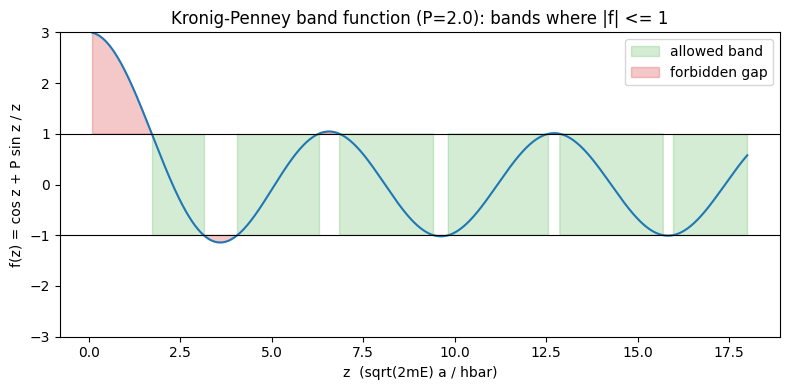

allowed fraction at P=2.0: 0.838  (rest is gaps)


In [2]:
z = np.linspace(0.1, 18, 4000); P = 2.0
f = kp.kp_rhs(z, P)
plt.figure(figsize=(8,4))
plt.plot(z, f, lw=1.5)
plt.axhline(1, color="k", lw=0.8); plt.axhline(-1, color="k", lw=0.8)
plt.fill_between(z, -1, 1, where=np.abs(f) <= 1, color="C2", alpha=0.2, label="allowed band")
plt.fill_between(z, f, np.sign(f), where=np.abs(f) > 1, color="C3", alpha=0.25, label="forbidden gap")
plt.ylim(-3, 3); plt.xlabel("z  (sqrt(2mE) a / hbar)"); plt.ylabel("f(z) = cos z + P sin z / z")
plt.title(f"Kronig-Penney band function (P={P}): bands where |f| <= 1"); plt.legend()
plt.tight_layout(); plt.show()
print(f"allowed fraction at P={P}: {kp.allowed_fraction(P):.3f}  (rest is gaps)")

## 2. The band structure E(K)

Inside each band, $Ka=\arccos f(z)$, so plotting energy $E\propto z^2$ against $Ka$
gives the **band structure**: curves that rise across the zone and then jump across a
**gap** to the next band. The empty horizontal strips are the forbidden energies.

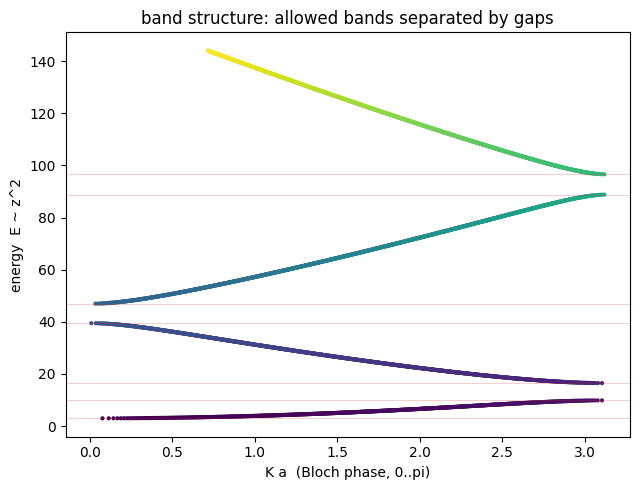

forbidden E-gaps appear as the empty horizontal strips between bands


In [3]:
Ka, E = kp.dispersion(P, z_max=12)
good = ~np.isnan(Ka)
plt.figure(figsize=(6.5,5))
plt.scatter(Ka[good], E[good], s=4, c=E[good], cmap="viridis")
for e in kp.band_edges(P, z_max=12):
    plt.axhline(e**2, color="C3", lw=0.4, alpha=0.4)
plt.xlabel("K a  (Bloch phase, 0..pi)"); plt.ylabel("energy  E ~ z^2")
plt.title("band structure: allowed bands separated by gaps"); plt.tight_layout(); plt.show()
print("forbidden E-gaps appear as the empty horizontal strips between bands")

## 3. The knob P -- from free electron to tight binding

$P$ is the lattice strength. At $P=0$ there are **no gaps** (the free electron, $E\sim
K^2$). As $P$ grows the bands **narrow** and the gaps widen -- toward isolated atomic
levels (the Bohr atom, reached from the solid-state side). Plotting the allowed
fraction vs $P$ shows the bands shrinking.

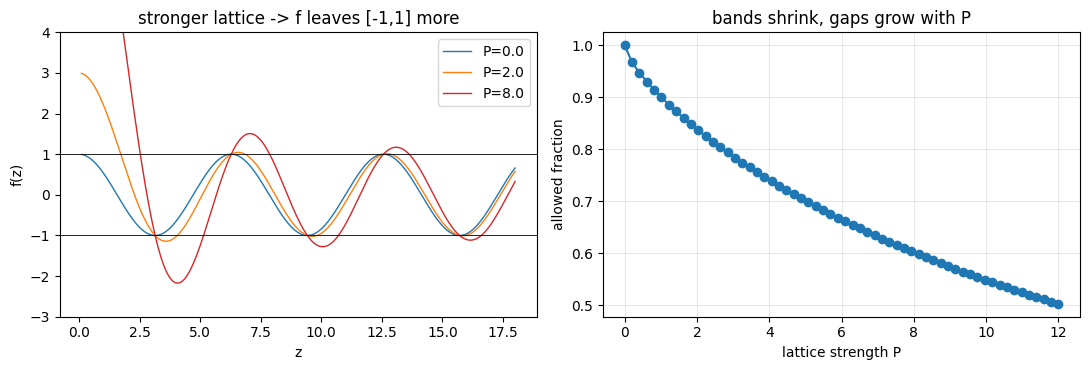

allowed fraction: P=0 -> 1.00 (free), P=12 -> 0.50 (tight binding)


In [4]:
Ps = np.linspace(0, 12, 60)
frac = [kp.allowed_fraction(p) for p in Ps]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for p, c in [(0.0,"C0"), (2.0,"C1"), (8.0,"C3")]:
    ax[0].plot(z, kp.kp_rhs(z, p), label=f"P={p}", color=c, lw=1)
ax[0].axhline(1,color="k",lw=0.6); ax[0].axhline(-1,color="k",lw=0.6); ax[0].set_ylim(-3,4)
ax[0].set(xlabel="z", ylabel="f(z)", title="stronger lattice -> f leaves [-1,1] more"); ax[0].legend()
ax[1].plot(Ps, frac, "o-"); ax[1].set(xlabel="lattice strength P", ylabel="allowed fraction",
          title="bands shrink, gaps grow with P"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"allowed fraction: P=0 -> {frac[0]:.2f} (free), P=12 -> {frac[-1]:.2f} (tight binding)")

## 4. The payoff: metal, insulator, semiconductor

Electrons fill the bands from the bottom (two per state, Pauli). What sits at the
**top of the filled stack** decides everything:
- a **partly filled** band -> electrons can move -> **metal**;
- a **filled band with a gap** above it -> no easy motion -> **insulator**;
- a filled band with a **small** gap -> a few electrons can be promoted (heat, light,
  doping) -> **semiconductor** -- the transistor, the diode, the solar cell.

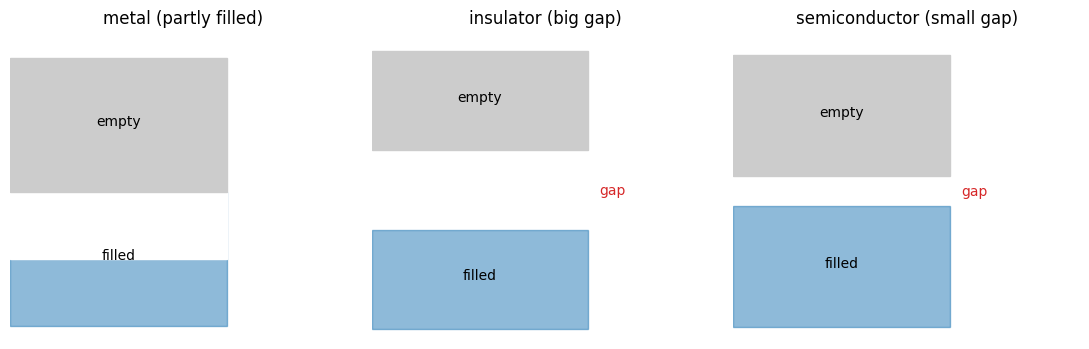

the band GAP, straight out of Kronig-Penney, is what makes a chip possible


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
def draw(ax, gap, fill_top, title):
    ax.add_patch(plt.Rectangle((0,0),1,1, color="C0", alpha=0.5))           # valence band
    if fill_top < 1: ax.add_patch(plt.Rectangle((0,fill_top),1,1-fill_top, color="w"))
    ax.add_patch(plt.Rectangle((0,1+gap),1,1, color="0.8"))                 # conduction band
    ax.text(0.5,0.5,"filled",ha="center"); ax.text(0.5,1.5+gap,"empty",ha="center")
    if gap>0: ax.text(1.05,1+gap/2,"gap",va="center",color="C3")
    ax.set(xlim=(0,1.6), ylim=(-0.1,2.2+gap), title=title); ax.axis("off")
draw(axes[0], 0.0, 0.5, "metal (partly filled)")
draw(axes[1], 0.8, 1.0, "insulator (big gap)")
draw(axes[2], 0.25, 1.0, "semiconductor (small gap)")
plt.tight_layout(); plt.show()
print("the band GAP, straight out of Kronig-Penney, is what makes a chip possible")

## What this replaces, and why it matters

1. The **Bohr atom's discrete levels** become **bands** once atoms form a periodic
   solid -- Kronig-Penney shows exactly how, from one $\cos(Ka)=f(z)$ condition.
2. A real $K$ exists only where $|f|\le1$: **allowed bands** and **forbidden gaps**.
3. The **gap** decides metal vs insulator vs semiconductor -- the physics every
   transistor, diode, LED, and solar cell runs on.

For a computer engineer, *this* is what comes after Bohr: band theory -> the band gap
-> semiconductor devices -> the chip. Civilian education.